# Electrostatic Complementarity (EC) calculation between ligand and protein

In [1]:
from pathlib import Path
import numpy as np
from scipy.stats import pearsonr
from scipy.spatial import cKDTree
from scipy.sparse import coo_matrix
from skimage import measure
import trimesh
import plotly.graph_objects as go
import plotly.express as px

## Создание гладкого меша

In [2]:
PROTEIN_CUTOFF = 15.0
DISTANCE_THRESHOLD = 6.0   # which atoms belong to the interface
GRID_PADDING = 2.0                   # Å, extra space around the interface
GRID_POINTS_PER_ANGSTROM = 1         # grid resolution
SDF_CUTOFF_RADIUS = 5.0              # max distance for smooth sum
SDF_SMOOTH_FACTOR = 1.5              # exponent sharpness


class SurfaceMesh(trimesh.base.Trimesh):
    """
        Класс для удобного хранения меша,
        чтобы не таскать несколько массивов
    """

    def __init__(self, vertices: np.ndarray, faces, normales, values=None):
        if values is None:
            values = np.zeros(vertices.shape[0])
        super().__init__(
            vertices=vertices,
            faces=faces,
            face_normals=normales,
            vertex_attributes=dict(
                values=values
            )
        )

    @property
    def values(self):
        return self.vertex_attributes.get("values")

    @classmethod
    def from_sdf(
            cls: "SurfaceMesh",
            sdf: np.ndarray,
            grd_xx: np.ndarray,
            grd_yy: np.ndarray,
            grd_zz: np.ndarray,
    ) -> "SurfaceMesh":
        # Вычисление начала координат сетки и spacing
        origin = np.asarray([
            grd_xx[0, 0, 0],
            grd_yy[0, 0, 0],
            grd_zz[0, 0, 0],
        ])
        spacing = (
            grd_xx[1, 0, 0] - grd_xx[0, 0, 0],
            grd_yy[0, 1, 0] - grd_yy[0, 0, 0],
            grd_zz[0, 0, 1] - grd_zz[0, 0, 0],
        )

        # Получение меша
        verts, faces, normals, values = measure.marching_cubes(sdf, level=0, spacing=spacing)

        # Сдвиг вершин на origin
        verts_physical = verts + origin

        # Обработка нормалей
        # Нормали уже в физическом пространстве, но могут нуждаться в перенормировке
        # если spacing анизотропный (разные в разных направлениях)
        normals_physical = normals / np.linalg.norm(normals, axis=1, keepdims=True)

        return cls(verts_physical, faces, normals_physical)


def find_neighbor_indexes(a_xyz, b_xyz,
                          distance_threshold=DISTANCE_THRESHOLD):
    a_tree = cKDTree(a_xyz)
    b_tree = cKDTree(b_xyz)

    a_neighbors_idx = list({nbr for nbr_list in a_tree.query_ball_point(b_xyz, distance_threshold)
                            for nbr in nbr_list})
    b_neighbors_idx = list({nbr for nbr_list in b_tree.query_ball_point(a_xyz, distance_threshold)
                            for nbr in nbr_list})
    return a_neighbors_idx, b_neighbors_idx


def make_interface_grid(a_xyz, b_xyz,
                        distance_threshold=DISTANCE_THRESHOLD,
                        grid_padding=GRID_PADDING,
                        grid_points_per_angstrom=GRID_POINTS_PER_ANGSTROM):
    a_neighbors_idx, b_neighbors_idx = find_neighbor_indexes(a_xyz, b_xyz, distance_threshold)
    interface_atoms = np.concatenate([a_xyz[a_neighbors_idx],
                                      b_xyz[b_neighbors_idx]], axis=0)

    limits = [(np.min(interface_atoms.T[i]), np.max(interface_atoms.T[i]))
              for i in range(3)]

    grd_xx, grd_yy, grd_zz = np.meshgrid(
        *(np.linspace(d_min - grid_padding,
                      d_max + grid_padding,
                      grid_points_per_angstrom * np.ceil(d_max - d_min + 2 * grid_padding).astype(int))
          for d_min, d_max in limits),
        indexing='ij')
    return grd_xx, grd_yy, grd_zz


def calculate_smooth_sdf(
        a_xyz: np.ndarray,
        a_vdw: np.ndarray,
        b_xyz: np.ndarray,
        b_vdw: np.ndarray,
        *,
        distance_threshold: float = 6.0,
        grid_padding: float = 0.0,
        grid_points_per_angstrom: int = 1,
        cutoff_radius: float = 5.0,
        smooth_factor: float = 1.5,
) -> np.ndarray:

    # вычисляем сетку
    grd_xx, grd_yy, grd_zz = make_interface_grid(a_xyz, b_xyz, distance_threshold, grid_padding,
                                                 grid_points_per_angstrom)

    # Собираем координаты узлов сетки в плоский массив точек [N*M*K, 3]
    grid_points = np.c_[
        grd_xx.ravel(),
        grd_yy.ravel(),
        grd_zz.ravel(),
    ]
    grid_tree = cKDTree(grid_points)

    # Храним координаты в виде KD-деревьев
    a_tree = cKDTree(a_xyz)
    b_tree = cKDTree(b_xyz)

    # Вычисляем расстояние до ближайших к точке сетки атомов и их индексы
    # Работаем с разреженной матрицей расстояний (формат COO)
    # i — индексы grid_xyz, j — индексы атомов
    a_sparse_dist = grid_tree.sparse_distance_matrix(a_tree, cutoff_radius, output_type='coo_matrix')
    # sparse_dist.data — это уже вычисленные расстояния d = |G - P|
    # sparse_dist.row — индексы точек сетки (i)
    # sparse_dist.col — индексы атомов (j)
    a_d_squared = np.power(a_sparse_dist.data, 2)
    a_vdw_squared = np.power(a_vdw[a_sparse_dist.col], 2)  # сопоставляем vdw по индексам
    a_exp_values = np.exp(-smooth_factor * (a_d_squared - a_vdw_squared))
    # Агрегируем значения обратно по строкам (по точкам сетки)
    # Используем np.bincount, это быстрее, чем преобразование в CSR и sum(axis=1)
    a_grid_sums = np.bincount(a_sparse_dist.row, weights=a_exp_values, minlength=len(grid_points))

    b_sparse_dist = grid_tree.sparse_distance_matrix(b_tree, cutoff_radius, output_type='coo_matrix')
    b_d_squared = np.power(b_sparse_dist.data, 2)
    b_vdw_squared = np.power(b_vdw[b_sparse_dist.col], 2)  # сопоставляем vdw по индексам
    b_exp_values = np.exp(-smooth_factor * (b_d_squared - b_vdw_squared))
    b_grid_sums = np.bincount(b_sparse_dist.row, weights=b_exp_values, minlength=len(grid_points))

    # Считаем SDF
    sdf_points = np.log(a_grid_sums + 1e-5) - np.log(b_grid_sums + 1e-5)
    sdf_tensor = sdf_points.reshape(grd_xx.shape)

    return sdf_tensor, grd_xx, grd_yy, grd_zz

## Функция визуализации со всеми настройками

In [4]:
def visualizer(lig_xyz, prot_xyz, lig_vdw, prot_vdw, smooth_mesh):
    lig_neighbors_idx, prot_neighbors_idx = find_neighbor_indexes(
        lig_xyz,
        prot_xyz,
        6.0,
    )

    prot_full = go.Scatter3d(
        x=prot_xyz.T[0],
        y=prot_xyz.T[1],
        z=prot_xyz.T[2],
        marker=go.scatter3d.Marker(
            color="#CD9EF7",
            size=prot_vdw * 3,
        ),
        mode="markers",
        name="Protein",
    )
    lig_full = go.Scatter3d(
        x=lig_xyz.T[0],
        y=lig_xyz.T[1],
        z=lig_xyz.T[2],
        marker=go.scatter3d.Marker(
            color="#64BAFF",
            size=lig_vdw * 3,
        ),
        mode="markers",
        name="Ligand",
    )
    prot_interface = go.Scatter3d(
        x=prot_xyz.T[0, prot_neighbors_idx],
        y=prot_xyz.T[1, prot_neighbors_idx],
        z=prot_xyz.T[2, prot_neighbors_idx],
        marker=go.scatter3d.Marker(
            color="#8A56B9",
            size=prot_vdw * 5,
            opacity=0.5,
        ),
        mode="markers",
        name="Protein Interface",
    )
    lig_interface = go.Scatter3d(
        x=lig_xyz.T[0, lig_neighbors_idx],
        y=lig_xyz.T[1, lig_neighbors_idx],
        z=lig_xyz.T[2, lig_neighbors_idx],
        marker=go.scatter3d.Marker(
            color="#317AB5",
            size=lig_vdw * 5,
            opacity=0.5,
        ),
        mode="markers",
        name="Ligand Interface",
    )

    # Получаем максимальное значение ЕС
    EC = np.abs(smooth_mesh.vertex_attributes['EC'])
    M = max(abs(EC)) if len(EC) > 0 else 1.0

    interface = go.Mesh3d(
        x=smooth_mesh.vertices.T[0],
        y=smooth_mesh.vertices.T[1],
        z=smooth_mesh.vertices.T[2],
        i=smooth_mesh.faces.T[0],
        j=smooth_mesh.faces.T[1],
        k=smooth_mesh.faces.T[2],
        opacity=0.5,
        flatshading=True,

        # Раскраска по локальным значениям ЕС
        intensity=EC,
        colorscale=[[0, 'green'], [0.5, 'white'], [1, 'red']],
        cmin=0,
        cmax=M,
        showscale=True,
        name="Interface EC",
    )

    x_edges, y_edges, z_edges = [], [], []
    for face in smooth_mesh.faces:
        for i in range(3):
            v0, v1 = face[i], face[(i + 1) % 3]
            x_edges.extend([smooth_mesh.vertices[v0, 0], smooth_mesh.vertices[v1, 0], None])
            y_edges.extend([smooth_mesh.vertices[v0, 1], smooth_mesh.vertices[v1, 1], None])
            z_edges.extend([smooth_mesh.vertices[v0, 2], smooth_mesh.vertices[v1, 2], None])

    fig = go.Figure(
        data=[
            prot_full,
            lig_full,
            prot_interface,
            lig_interface,
            interface,
        ],
    )

    fig.update_layout(
        width=1200,
        height=900,
        scene=dict(
            xaxis=dict(range=[lig_xyz.T[0].min() - 10, lig_xyz.T[0].max() + 10]),
            yaxis=dict(range=[lig_xyz.T[1].min() - 10, lig_xyz.T[1].max() + 10]),
            zaxis=dict(range=[lig_xyz.T[2].min() - 10, lig_xyz.T[2].max() + 10]),
            aspectmode='data'  # Кубические пропорции — иногда помогает
        ),
        legend=dict(
            x=0.02,           # place legend near left edge
            y=0.98,           # near top edge
            xanchor='left',
            yanchor='top',
            bgcolor='rgba(255,255,255,0.7)'   # semi-transparent background for readability
        ),
        margin=dict(r=120)    # extra space on right for the colorbar

    )

    fig.show()

## Функция для парсинга входных .pqr файлов

In [5]:
def parse_pqr(pqr_file: str) -> tuple[np.array, np.array, np.array]:
    """
    Извлечение координат, зарядов и радиусов атомов из pqr-файла
    """
    coords, charges, radii = [], [], []
    with open(pqr_file, 'r') as f:
        for line in f:
            if line.startswith(("ATOM", "HETATM")):
                parts = line.split()
                radii.append(float(parts[-1]))
                charges.append(float(parts[-2]))
                coords.append([float(parts[-5]), float(parts[-4]), float(parts[-3])])

    return np.array(coords), np.array(charges), np.array(radii)

## Функция для расчета потенциалов (ESP)

In [6]:
def calc_esp(
        atom_coords: np.ndarray,
        atom_charges: np.ndarray,
        surface_coords: np.ndarray
) -> np.array:
    """
    Вычисление относительного электростатического потенциала (без учета 1/4pi*e0 из-за корреляции Пирсона).
    """
    esp_values = []
    tree = cKDTree(atom_coords)
    surf_tree = cKDTree(surface_coords)
    sparse_dist = surf_tree.sparse_distance_matrix(tree, PROTEIN_CUTOFF, output_type='coo_matrix')
    distances = sparse_dist.data
    rows = sparse_dist.row
    cols = sparse_dist.col

    relevant_charges = atom_charges[cols]
    partial_potentials = relevant_charges / (distances + 1e-10)
    potentials = np.bincount(rows, weights=partial_potentials, minlength=len(surface_coords))

    return potentials

## Основной пайплайн

In [7]:
def main(lig_pqr, prot_pqr):
    l_data = parse_pqr(lig_pqr)
    p_data = parse_pqr(prot_pqr)
    if not l_data or not p_data: return None

    l_coords, l_charges, l_radii = l_data
    p_coords, p_charges, p_radii = p_data

    # 2. Генерация гладкого интерфейса
    print(f"   - Computing smooth SDF interface...")
    s_sdf, grd_xx, grd_yy, grd_zz = calculate_smooth_sdf(
        l_coords, l_radii,
        p_coords, p_radii,
        distance_threshold=DISTANCE_THRESHOLD,
        grid_padding=GRID_PADDING,
        grid_points_per_angstrom=GRID_POINTS_PER_ANGSTROM,
        cutoff_radius=SDF_CUTOFF_RADIUS,
        smooth_factor=SDF_SMOOTH_FACTOR
    )

    # 3. Получение изоповерхности
    print(f"   - Creating smooth isosurface...")
    mesh = SurfaceMesh.from_sdf(s_sdf, grd_xx, grd_yy, grd_zz)

    # 4. Расчет ESP
    print(f"   - Calculating ESP values...")
    surf_points = mesh.vertices
    v_lig = calc_esp(l_coords, l_charges, surf_points)
    v_prot = calc_esp(p_coords, p_charges, surf_points)

    # 5. Корреляция по Пирсону
    print(f"   - Calculating Pearson correlation...")
    corr, _ = pearsonr(v_lig, v_prot)
    print(corr)

    # 6. Локальные ЕС
    print(f"   - Calculating local EC values...")
    EC = v_lig + v_prot
    mesh.vertex_attributes['EC'] = EC

    # 7. Визуал
    visualizer(l_coords, p_coords, l_radii, p_radii, mesh)

# Запуск пайплайна

   - Computing smooth SDF interface...
   - Creating smooth isosurface...
   - Calculating ESP values...
   - Calculating Pearson correlation...
-0.504147699208289
   - Calculating local EC values...


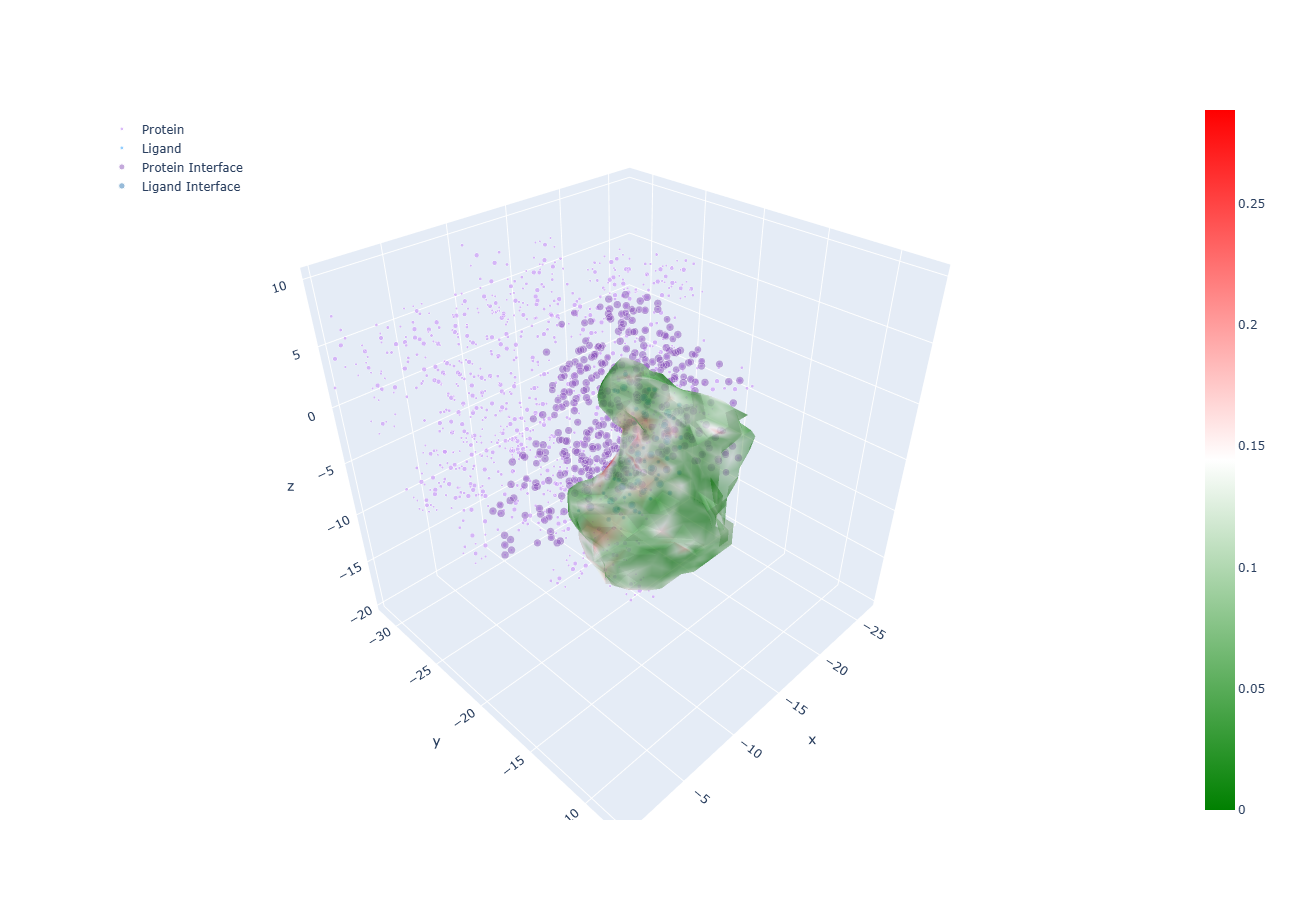

In [8]:
ligand_pqr = Path("example/lig1_charged.pqr")
protein_pqr = Path("example/5c7a_charged.pqr")

main(ligand_pqr, protein_pqr)